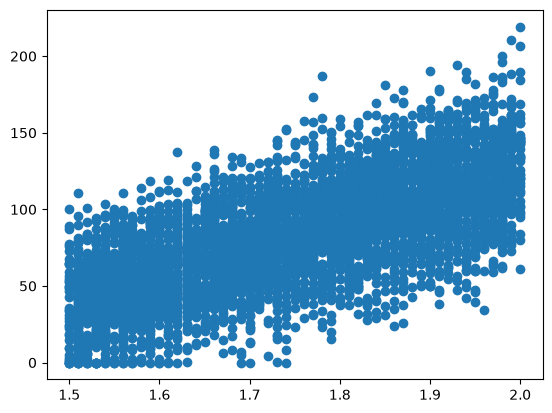

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

data=json.load(open('estatura_peso.json'))
h=[row['height'] for row in data]
w=[row['weight'] for row in data]
plt.plot(h,w,'o')
#Esta gráfica de dispersión no es tan representativa pues muestra una región, pero no dónde hay más puntos que en otras regiones

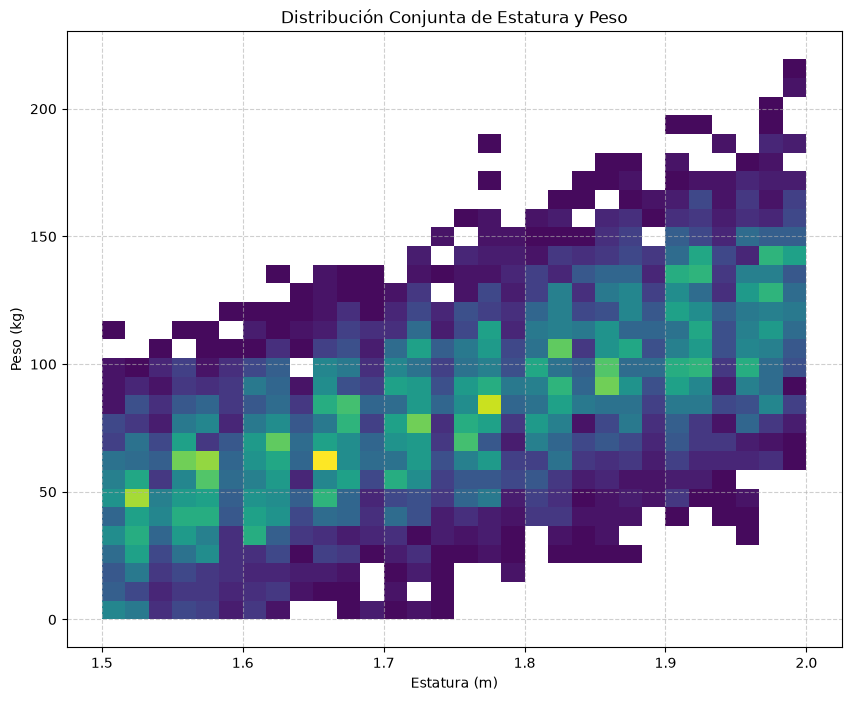

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the list of dictionaries to a pandas DataFrame
df_data = pd.DataFrame(data)

# Create a 2D histogram (heatmap-like) using seaborn.histplot
fig = plt.figure(figsize=(10, 8))
sns.histplot(data=df_data, x='height', y='weight', bins=30, cmap='viridis')
plt.title('Distribución Conjunta de Estatura y Peso')
plt.xlabel('Estatura (m)')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


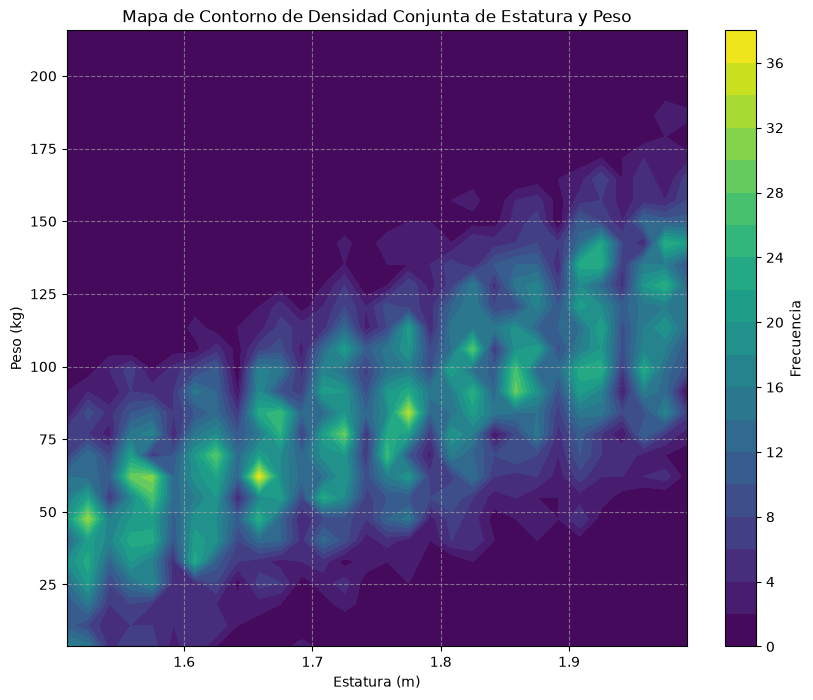

In [8]:
#Una mejor manera de verlo es relacionado esto con una superficie en tres dimensiones.
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for the plot
x = df_data['height']
y = df_data['weight']

# Create 2D histogram
hist, xedges, yedges = np.histogram2d(x, y, bins=30)

# Create meshgrid for the contour plot
X, Y = np.meshgrid(xedges[:-1] + np.diff(xedges)/2, yedges[:-1] + np.diff(yedges)/2)
Z = hist.T # Transpose Z to match X and Y dimensions properly

# Create the contour plot
fig = plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=20, cmap='viridis')

# Add labels and title
plt.xlabel('Estatura (m)')
plt.ylabel('Peso (kg)')
plt.title('Mapa de Contorno de Densidad Conjunta de Estatura y Peso')

# Add a color bar
plt.colorbar(label='Frecuencia')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


De acuerdo con los valores anteriores podemos suponer que el modelo es gaussiano, 
con media dada por la ecuación siguiente y 
con desviación estándar definida por la otra ecuación

--- Ecuación para la media del peso (Wm) ---
Wm = 171.34 * h + -216.61

--- Ecuación para la desviación estándar del peso (Std_w) ---
Std_w = 11.37 * h + 6.40


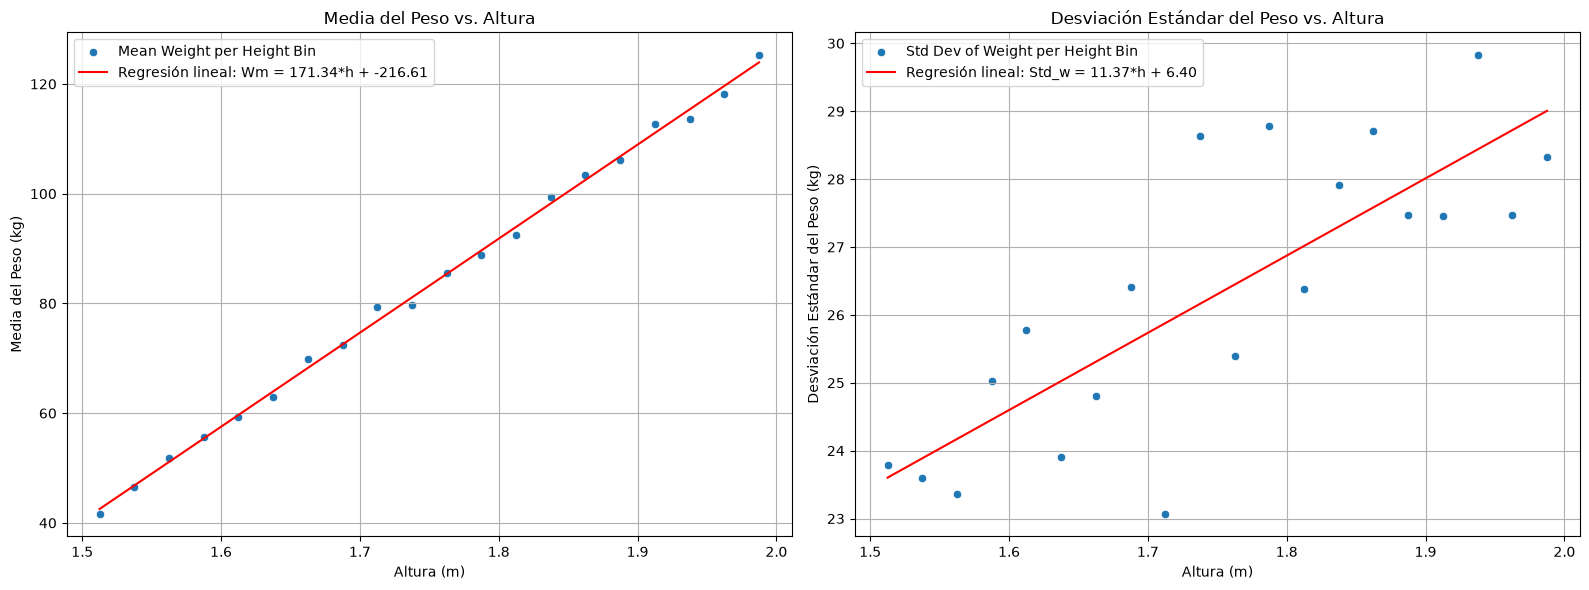

In [11]:
#Entonces se puede pensar un modelo que permita estimar el peso como algo normal en cada estatura, calculando para diferentes rangos de h el valor medio y la desviación estándar de w, y luego graficar la distribución normal para cada rango de h. Esto nos permitirá ver cómo se distribuye el peso para diferentes estaturas y cómo varía la media y la desviación estándar.
from scipy.stats import linregress

# Define the number of bins for height
num_height_bins = 20

# Create bins for height and get the bin labels/midpoints
# We'll use pd.cut to discretize the 'height' column
df_data['height_bin'] = pd.cut(
    df_data['height'],
    bins=num_height_bins,
    labels=False, # Use integer labels for bins
    include_lowest=True
)

# Calculate the midpoint of each height bin
# Get the bin edges
height_min = df_data['height'].min()
height_max = df_data['height'].max()
bin_edges = np.linspace(height_min, height_max, num_height_bins + 1)

# Calculate bin midpoints
bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2

# Map bin labels to midpoints for analysis
df_data['height_bin_midpoint'] = df_data['height_bin'].map(lambda x: bin_midpoints[x])

# Group by height bins and calculate mean and standard deviation of weight
grouped_data = df_data.groupby('height_bin_midpoint').agg(
    mean_weight=('weight', 'mean'),
    std_dev_weight=('weight', 'std')
).reset_index()

# --- Regression for Mean Weight (Wm = m_mean * h + b_mean) ---
# Filter out NaN values that might arise if a bin is empty or has only one data point for std_dev
filtered_grouped_data = grouped_data.dropna(subset=['mean_weight'])

# Perform linear regression for mean weight vs. height bin midpoint
# Independent variable (x) is height_bin_midpoint, dependent variable (y) is mean_weight
mean_reg_result = linregress(
    filtered_grouped_data['height_bin_midpoint'],
    filtered_grouped_data['mean_weight']
)
m_mean, b_mean = mean_reg_result.slope, mean_reg_result.intercept

# --- Regression for Standard Deviation of Weight (Std_w = m_std * h + b_std) ---
# Filter out NaN values for std_dev_weight
filtered_grouped_data_std = grouped_data.dropna(subset=['std_dev_weight'])

# Perform linear regression for std dev of weight vs. height bin midpoint
# Independent variable (x) is height_bin_midpoint, dependent variable (y) is std_dev_weight
std_reg_result = linregress(
    filtered_grouped_data_std['height_bin_midpoint'],
    filtered_grouped_data_std['std_dev_weight']
)
m_std, b_std = std_reg_result.slope, std_reg_result.intercept

print('De acuerdo con los valores anteriores podemos suponer que el modelo es gaussiano, \ncon media dada por la ecuación siguiente y \ncon desviación estándar definida por la otra ecuación')

print("\n--- Ecuación para la media del peso (Wm) ---")
print(f"Wm = {m_mean:.2f} * h + {b_mean:.2f}")


print("\n--- Ecuación para la desviación estándar del peso (Std_w) ---")
print(f"Std_w = {m_std:.2f} * h + {b_std:.2f}")

# You can also visualize these regressions:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Mean Weight
sns.scatterplot(
x='height_bin_midpoint', 
y='mean_weight', 
data=grouped_data, 
ax=axes[0],
label='Mean Weight per Height Bin'
)
axes[0].plot(
    filtered_grouped_data['height_bin_midpoint'],
    m_mean * filtered_grouped_data['height_bin_midpoint'] + b_mean,
    color='red',
    label=f'Regresión lineal: Wm = {m_mean:.2f}*h + {b_mean:.2f}'
)
axes[0].set_title('Media del Peso vs. Altura')
axes[0].set_xlabel('Altura (m)')
axes[0].set_ylabel('Media del Peso (kg)')
axes[0].legend()
axes[0].grid(True)

# Plot for Standard Deviation of Weight
sns.scatterplot(
    x='height_bin_midpoint',
    y='std_dev_weight',
    data=grouped_data,
    ax=axes[1],
    label='Std Dev of Weight per Height Bin'
)
axes[1].plot(
    filtered_grouped_data_std['height_bin_midpoint'],
    m_std * filtered_grouped_data_std['height_bin_midpoint'] + b_std,
    color='red',
    label=f'Regresión lineal: Std_w = {m_std:.2f}*h + {b_std:.2f}'
)
axes[1].set_title('Desviación Estándar del Peso vs. Altura')
axes[1].set_xlabel('Altura (m)')
axes[1].set_ylabel('Desviación Estándar del Peso (kg)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Es necesario sin embargo, estudiar si este modelo es una buena representación de la realidad. Pero por ahora, creo que es entendible que el modelo es mucho más comprimido que los datos originales. 